<a href="https://colab.research.google.com/github/SoumyaSriPerepu/AIPortfolio/blob/main/BreastCancertoBoneCancer.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Corrected GCN Bone Metastasis Prediction Pipeline (with Visualizations)

**What changed from the original notebook, and why:**

1. **Leakage fix (DEG selection):** Original ran gene selection (limma) on all 184 patients before the train/test split, letting test-patient labels influence which genes were chosen. Fixed by moving DEG selection inside each cross-validation fold, using only that fold's training patients.
2. **Evaluation fix (single split -> k-fold):** Original used one 80/20 split (only 7 positive test cases). Fixed with stratified 5-fold cross-validation; every patient is evaluated exactly once, and the final metric is mean +/- std across folds.
3. **Class imbalance fix:** 151 no-bone-met vs. 33 bone-met (~4.6:1). Fixed with class-weighted loss, computed fresh per fold from that fold's own training label counts.
4. **Feature standardization fix:** Added a StandardScaler fit only on training-fold patients, applied to both train and test patients in that fold.
5. **Left as intentional simplification:** Quantile normalization is still applied to the whole expression matrix up front (unsupervised, so leakage risk is much smaller, but not perfectly leakage-free).

**New in this version:** data preview cells, a PPI network graph visualization, and result visualizations (per-fold bar charts, ROC curves, confusion matrix heatmaps, robust-gene chart).

Requirements: torch, torch_geometric, rpy2, networkx, requests, scikit-learn, matplotlib, seaborn, and R with GEOquery + limma + Biobase.

In [27]:
# Cell 1: Environment setup
!pip install torch torch-geometric requests networkx scikit-learn matplotlib seaborn -q
# R packages: BiocManager::install(c("GEOquery","limma","Biobase"))



In [28]:
import rpy2.robjects as ro
from rpy2.robjects import pandas2ri
import pandas as pd
import numpy as np
import torch
import torch.nn.functional as F
from torch_geometric.data import Data
from torch_geometric.loader import DataLoader
from torch_geometric.nn import GCNConv, global_mean_pool
from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import roc_curve, auc, confusion_matrix, classification_report
import requests
import networkx as nx
from collections import Counter
import matplotlib.pyplot as plt
import seaborn as sns



In [29]:
pandas2ri.activate()
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

Using device: cpu


In [30]:
#Data acquisition : run ONCE, not per fold

r_code_download = """
if (!requireNamespace("BiocManager", quietly = TRUE))
    install.packages("BiocManager", repos="https://cran.r-project.org")
BiocManager::install(c("GEOquery", "Biobase"), ask=FALSE, update=FALSE)

library(GEOquery)
library(Biobase)

gse <- getGEO("GSE175692", GSEMatrix=TRUE, getGPL=FALSE)
eset <- gse[[1]]

expr_matrix <- exprs(eset)
pheno_data  <- pData(eset)

write.csv(expr_matrix, "/content/expression_matrix.csv")
write.csv(pheno_data,  "/content/pheno_data.csv")

cat("Expression matrix shape:", nrow(expr_matrix), "genes x", ncol(expr_matrix), "samples\n")
"""
ro.r(r_code_download)
print("GSE175692 downloaded successfully!")

'help("repositories", package = "BiocManager")' for details.
Replacement repositories:
    CRAN: https://cran.rstudio.com







Expression matrix shape: 771 genes x 184 samples



  `force = TRUE` to re-install: 'GEOquery' 'Biobase' 



GSE175692 downloaded successfully!


In [31]:
# Build sample labels ONCE
# (labels alone don't leak anything -- only USING them for feature selection
# on test patients is the problem, which is what the fold loop below avoids)
r_code_labels = """
library(Biobase)
pheno <- read.csv("/content/pheno_data.csv", row.names=1)

label_col <- NULL
for (col in colnames(pheno)) {
  vals <- tolower(as.character(pheno[[col]]))
  if (any(grepl("bone", vals)) | any(grepl("metastas", vals))) {
    label_col <- col
    break
  }
}
if (is.null(label_col)) {
  label_col <- grep("characteristics", colnames(pheno), value=TRUE)[1]
}

group <- ifelse(grepl("bone", tolower(as.character(pheno[[label_col]]))),
                "bone_met", "no_bone_met")

write.csv(data.frame(sample=rownames(pheno), group=group),
          "/content/sample_labels.csv", row.names=FALSE)
cat("Label distribution:\n")
print(table(group))
"""
ro.r(r_code_labels)



Label distribution:
group
   bone_met no_bone_met 
         33         151 


In [32]:
labels_df = pd.read_csv("/content/sample_labels.csv")
labels_df['label_binary'] = (labels_df['group'] == 'bone_met').astype(int)
print(labels_df['group'].value_counts())

group
no_bone_met    151
bone_met        33
Name: count, dtype: int64


In [33]:
# Quantile-normalize expression ONCE (unsupervised -- see note above)
r_code_norm = """
library(limma)
expr <- read.csv("/content/expression_matrix.csv", row.names=1)
expr_norm <- normalizeBetweenArrays(as.matrix(expr), method="quantile")
write.csv(expr_norm, "/content/expression_normalized.csv")
cat("Normalization complete.\n")
"""


In [34]:
ro.r(r_code_norm)
expr_df_full = pd.read_csv("/content/expression_normalized.csv", index_col=0)
print(f"Expression matrix: {expr_df_full.shape[0]} genes x {expr_df_full.shape[1]} samples")

Normalization complete.
Expression matrix: 771 genes x 184 samples


## Data Preview (NEW)

A quick look at the input data before it goes into the pipeline: the raw/normalized expression matrix and the label distribution.

In [35]:
# NEW CELL: Preview the expression matrix (input data)
print("Expression matrix shape:", expr_df_full.shape)


Expression matrix shape: (771, 184)


In [66]:
print("\nFirst 40 genes x first 40 patients:")
display(expr_df_full.iloc[:40, :40])



First 40 genes x first 40 patients:


,GSM5344040,GSM5344041,GSM5344042,GSM5344043,GSM5344044,GSM5344045,GSM5344046,GSM5344047,GSM5344048,GSM5344049,...,GSM5344070,GSM5344071,GSM5344072,GSM5344073,GSM5344074,GSM5344075,GSM5344076,GSM5344077,GSM5344078,GSM5344079
ABCA8,-6.880714,-6.507461,-7.690607,-4.938676,-5.999609,-6.427090,-6.175854,-5.242821,-4.976001,-4.340895,...,-4.130362,-4.874941,-6.887813,-4.270100,-6.004772,-2.123585,-2.104295,-4.753019,-4.184588,-4.930010
ABCF1,-2.194728,-2.271990,-2.725716,-1.962304,-2.231162,-1.837350,-2.645726,-1.919345,-2.284887,-2.123585,...,-1.868894,-1.464175,-2.091413,-2.391457,-6.004772,-2.803521,-2.949768,-2.276221,-2.552081,-2.377865
ACTR3B,-3.365542,-3.025425,-3.381542,-2.204948,-3.534813,-4.835740,-3.815289,-2.965224,-3.014011,-2.400334,...,-2.058407,-2.123585,-3.765956,-2.476403,-5.206875,-3.290851,-2.884216,-3.254915,-4.003941,-4.456772
ACVR1B,-3.442605,-2.591616,-3.175857,-2.181962,-2.657106,-3.250957,-3.210246,-2.622403,-2.452050,-2.253858,...,-2.204948,-2.468522,-2.758043,-1.304802,-4.517748,-3.172051,-2.492829,-2.766306,-2.480304,-2.734120
ACVR1C,-7.862511,-9.477597,-7.264993,-8.317289,-5.999609,-6.831314,-5.442192,-7.905546,-7.070163,-6.307820,...,-6.938789,-5.876457,-8.589163,-7.701026,-5.206875,-6.978181,-3.904176,-7.133693,-9.858977,-6.532342
ACVRL1,-4.305958,-3.394217,-5.606038,-4.305958,-5.308981,-2.468522,-4.250171,-2.869429,-3.575533,-3.607032,...,-3.839468,-3.951121,-3.312963,-4.122356,-5.206875,-4.236164,-3.213972,-3.639012,-2.930417,-2.484205
ADAM12,-3.568698,-6.168731,-5.089827,-4.453156,-6.418702,-0.369677,-5.442192,-0.925086,-0.866922,-0.943669,...,-3.369189,-3.973498,-4.033200,-5.777670,-7.677782,-4.393633,-3.386947,-2.909425,-0.885761,-4.930010
ADCY9,-1.608506,-2.979626,-3.041087,-2.140568,-2.118438,-2.817241,-4.789691,-2.965224,-2.669407,-1.962304,...,-2.813849,-1.666778,-3.003242,-1.747967,-1.874207,-2.599951,-2.302008,-2.327585,-2.860941,-2.599951
ADD1,-1.217708,-1.326928,-1.672305,-1.232882,-1.753859,-1.319572,-0.961931,-1.186974,-0.827882,-0.805149,...,-0.767753,-0.977927,-2.030148,-0.664814,-1.283698,-0.664814,-0.642607,-0.340486,-1.054014,-0.906393
ADM,-3.327555,-3.530745,-2.975863,-5.588469,-5.600192,-1.232882,-2.043728,-3.834964,-4.011808,-4.145097,...,-3.808118,-3.152295,-3.275526,-5.232637,-2.464558,-3.889038,-2.979626,-5.707815,-4.593357,-4.456772


In [37]:
print("\nExpression value summary (all genes/patients):")
display(expr_df_full.stack().describe().to_frame(name="value"))


Expression value summary (all genes/patients):


,value
count,141649.000000
mean,-3.931660
std,2.311107
min,-10.625760
25%,-5.568427
50%,-3.851850
75%,-2.358433
max,3.761718


In [38]:
# NEW CELL: Preview labels + class balance chart
print("Sample labels preview:")
display(labels_df.head(10))



Sample labels preview:


,sample,group,label_binary
0,GSM5344040,bone_met,1
1,GSM5344041,no_bone_met,0
2,GSM5344042,no_bone_met,0
3,GSM5344043,bone_met,1
4,GSM5344044,bone_met,1
5,GSM5344045,bone_met,1
6,GSM5344046,no_bone_met,0
7,GSM5344047,no_bone_met,0
8,GSM5344048,no_bone_met,0
9,GSM5344049,no_bone_met,0


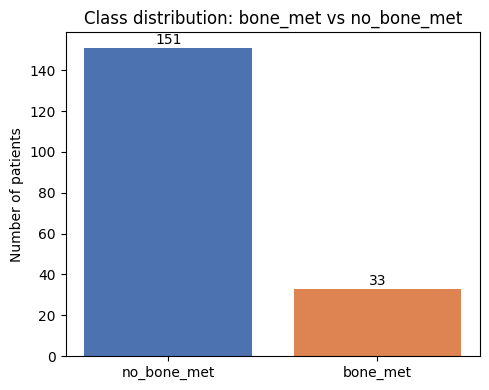

In [39]:
fig, ax = plt.subplots(figsize=(5, 4))
counts = labels_df['group'].value_counts()
bars = ax.bar(counts.index, counts.values, color=["#4C72B0", "#DD8452"])
ax.set_title("Class distribution: bone_met vs no_bone_met")
ax.set_ylabel("Number of patients")
for bar, val in zip(bars, counts.values):
    ax.text(bar.get_x() + bar.get_width()/2, val + 2, str(val), ha="center")
plt.tight_layout()
plt.savefig("/content/class_distribution.png", dpi=150)
plt.show()

In [40]:
# FOLD-SCOPED FUNCTIONS - this is the core of the leakage fix.
# Everything here is computed using ONLY the patient IDs passed in as train_ids.

def run_deg_analysis_train_only(train_sample_ids, labels_df):
    """
    Run limma DEG analysis using ONLY the training fold's samples and labels.
    This is the key leakage fix: test patients' labels never touch this step.
    """
    train_ids_r = ro.StrVector(train_sample_ids)
    ro.globalenv['train_ids'] = train_ids_r

    r_code_deg = """
    library(limma)
    expr_norm <- read.csv("/content/expression_normalized.csv", row.names=1)
    labels <- read.csv("/content/sample_labels.csv")

    train_expr <- expr_norm[, colnames(expr_norm) %in% train_ids]
    train_labels <- labels[labels$sample %in% train_ids, ]
    train_labels <- train_labels[match(colnames(train_expr), train_labels$sample), ]

    group <- factor(train_labels$group)
    design <- model.matrix(~0 + group)
    colnames(design) <- levels(group)

    fit  <- lmFit(as.matrix(train_expr), design)
    cont <- makeContrasts(bone_met - no_bone_met, levels=design)
    fit2 <- contrasts.fit(fit, cont)
    fit2 <- eBayes(fit2)

    degs <- topTable(fit2, number=Inf, lfc=1, p.value=0.05)
    write.csv(degs, "/content/fold_DEGs.csv")
    cat("Fold DEGs found:", nrow(degs), "\n")
    """
    ro.r(r_code_deg)
    degs_df = pd.read_csv("/content/fold_DEGs.csv", index_col=0)
    return degs_df.sort_values('adj.P.Val').head(200).index.tolist()




In [41]:
def query_string_api(gene_list, species=9606, score_threshold=400):
    genes_str = "%0d".join(gene_list)
    url = "https://string-db.org/api/json/network"
    params = {
        "identifiers": genes_str,
        "species": species,
        "required_score": score_threshold,
        "caller_identity": "breast_cancer_gcn_project_cv"
    }
    response = requests.post(url, data=params)
    if response.status_code != 200:
        print(f"STRING API error: {response.status_code}")
        return []
    return response.json()




In [42]:
def build_ppi_graph(top_genes):
    """Build PPI graph from STRING; fall back to literature-based graph if too few edges."""
    interactions = query_string_api(top_genes, score_threshold=400)
    G = nx.Graph()
    for gene in top_genes:
        G.add_node(gene)
    for edge in interactions:
        gene_a = edge.get('preferredName_A', edge.get('stringId_A', ''))
        gene_b = edge.get('preferredName_B', edge.get('stringId_B', ''))
        score = edge.get('score', 0)
        if gene_a and gene_b and score > 0.4:
            G.add_edge(gene_a, gene_b, weight=score)

    if G.number_of_edges() < 10:
        print("  WARNING: too few STRING interactions, using literature fallback graph")
        known_hub_genes = [
            'SMAD7', 'TGFBR2', 'VIM', 'FOS', 'PDGFRB',
            'PROM1', 'RAC2', 'PIAS1', 'EP300', 'EIF2S1',
            'LRP6', 'MMP9', 'CXCL12', 'PTHLH', 'RUNX2',
            'BMP2', 'IL6', 'VEGFA', 'CDH1', 'CDH2',
            'TWIST1', 'SNAI1', 'ZEB1', 'MKI67', 'ESR1'
        ]
        known_edges = [
            ('SMAD7', 'TGFBR2'), ('SMAD7', 'BMP2'), ('TGFBR2', 'RUNX2'),
            ('RUNX2', 'MMP9'), ('MMP9', 'CXCL12'), ('CXCL12', 'VEGFA'),
            ('VEGFA', 'IL6'), ('IL6', 'PIAS1'), ('PIAS1', 'EP300'),
            ('EP300', 'FOS'), ('FOS', 'VIM'), ('VIM', 'CDH2'),
            ('CDH2', 'TWIST1'), ('TWIST1', 'SNAI1'), ('SNAI1', 'ZEB1'),
            ('ZEB1', 'CDH1'), ('CDH1', 'ESR1'), ('ESR1', 'MKI67'),
            ('PDGFRB', 'LRP6'), ('LRP6', 'RAC2'), ('RAC2', 'EIF2S1'),
            ('PTHLH', 'RUNX2'), ('PTHLH', 'BMP2'), ('PROM1', 'CXCL12'),
            ('VEGFA', 'MMP9'), ('IL6', 'SMAD7'), ('EP300', 'RUNX2'),
        ]
        G = nx.Graph()
        G.add_nodes_from(known_hub_genes)
        G.add_edges_from(known_edges)
        np.random.seed(42)
        for _ in range(40):
            a, b = np.random.choice(known_hub_genes, 2, replace=False)
            G.add_edge(a, b, weight=np.random.uniform(0.4, 1.0))
        top_genes = known_hub_genes

    return G, top_genes




In [43]:
def build_patient_graph(patient_id, G, expr_df, labels_df):
    nodes = list(G.nodes())
    node_to_idx = {gene: i for i, gene in enumerate(nodes)}
    node_features = []
    for gene in nodes:
        if gene in expr_df.index and patient_id in expr_df.columns:
            val = float(expr_df.loc[gene, patient_id])
        else:
            val = 0.0
        node_features.append([val])
    x = torch.tensor(node_features, dtype=torch.float)

    edge_list = list(G.edges())
    if len(edge_list) == 0:
        edge_index = torch.zeros((2, 0), dtype=torch.long)
    else:
        src = [node_to_idx[e[0]] for e in edge_list]
        dst = [node_to_idx[e[1]] for e in edge_list]
        edge_index = torch.tensor([src + dst, dst + src], dtype=torch.long)

    row = labels_df[labels_df['sample'] == patient_id]
    label = int(row['label_binary'].values[0]) if len(row) > 0 else 0
    y = torch.tensor([label], dtype=torch.long)

    return Data(x=x, edge_index=edge_index, y=y)

## PPI Network Preview (NEW)

The pipeline builds a fresh PPI graph inside every fold, but it was never actually plotted before. This cell runs the DEG + PPI construction once on the *full* training-eligible cohort just to visualize what one of these graphs looks like -- this preview graph is for illustration only and is **not** used for any model training (the real per-fold graphs are built fresh inside the cross-validation loop in Cell 7).

In [44]:
# NEW CELL: Visualize a sample PPI network (illustration only, not used in training)
preview_ids = labels_df['sample'].tolist()
preview_genes = run_deg_analysis_train_only(preview_ids, labels_df)
G_preview, preview_genes = build_ppi_graph(preview_genes)

print(f"Preview PPI graph: {G_preview.number_of_nodes()} nodes, {G_preview.number_of_edges()} edges")



Fold DEGs found: 68 
Preview PPI graph: 68 nodes, 254 edges


{'IBSP': Text(-0.35924617016742133, 0.040648405282039377, 'IBSP'),
 'WIF1': Text(-0.4136341288062925, -0.09344900449082028, 'WIF1'),
 'ITGB3': Text(-0.23115535169940138, -0.1208653186758343, 'ITGB3'),
 'CHAD': Text(-0.8078870255639915, 0.09670211714746613, 'CHAD'),
 'VIT': Text(0.41200883048951403, 0.8051154130925252, 'VIT'),
 'BMP2': Text(-0.18166283473431555, -0.18187838788561803, 'BMP2'),
 'MMP9': Text(-0.04121850500836469, 0.04228157684270178, 'MMP9'),
 'HBB': Text(-0.5749785519912384, -0.026952981960049877, 'HBB'),
 'EYA1': Text(-0.4529454179254994, -0.4364332383925568, 'EYA1'),
 'GREM1': Text(-0.3806779326295417, -0.3387921649336677, 'GREM1'),
 'WNT5B': Text(-0.5015525940208179, -0.2862220401631723, 'WNT5B'),
 'FZD8': Text(-0.4938525608363635, -0.4690724295240683, 'FZD8'),
 'OLFML2B': Text(0.09572571113481802, 0.9013941635254086, 'OLFML2B'),
 'CCL2': Text(0.12829838216937367, 0.018741670924001252, 'CCL2'),
 'FLNC': Text(-0.11928025714811662, -0.6734939719830916, 'FLNC'),
 'BMP5':

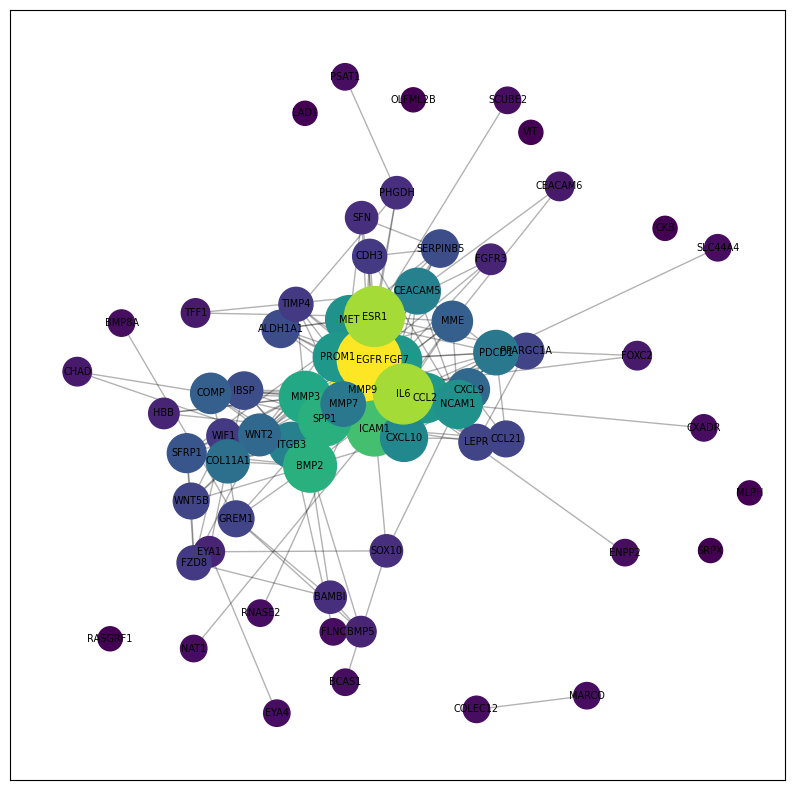

In [45]:
fig, ax = plt.subplots(figsize=(10, 10))
pos = nx.spring_layout(G_preview, seed=42, k=0.5)

degrees = dict(G_preview.degree())
node_sizes = [300 + 60 * degrees[n] for n in G_preview.nodes()]
node_colors = [degrees[n] for n in G_preview.nodes()]

nx.draw_networkx_edges(G_preview, pos, alpha=0.3, ax=ax)
nodes = nx.draw_networkx_nodes(G_preview, pos, node_size=node_sizes,
                                node_color=node_colors, cmap="viridis", ax=ax)
nx.draw_networkx_labels(G_preview, pos, font_size=7, ax=ax)



In [46]:
plt.colorbar(nodes, ax=ax, label="Node degree (# interactions)", shrink=0.8)
ax.set_title("Gene-Gene Protein-Protein Interaction (PPI) Network\n(node size/color = degree)")
ax.axis("off")
plt.tight_layout()
plt.savefig("/content/ppi_network_preview.png", dpi=150)
plt.show()

top_hub = sorted(degrees.items(), key=lambda x: -x[1])[:10]
print("\nTop 10 hub genes by degree in this preview graph:")
for gene, deg in top_hub:
    print(f"  {gene}: {deg} interactions")

/tmp/ipykernel_1505/1752335616.py:1: UserWarning: Adding colorbar to a different Figure <Figure size 1000x1000 with 2 Axes> than <Figure size 640x480 with 0 Axes> which fig.colorbar is called on.
  plt.colorbar(nodes, ax=ax, label="Node degree (# interactions)", shrink=0.8)


<Figure size 640x480 with 0 Axes>


Top 10 hub genes by degree in this preview graph:
  MMP9: 30 interactions
  EGFR: 30 interactions
  IL6: 26 interactions
  ESR1: 26 interactions
  ICAM1: 21 interactions
  BMP2: 19 interactions
  SPP1: 19 interactions
  MMP3: 18 interactions
  CCL2: 16 interactions
  PROM1: 16 interactions


In [47]:
#  GCN architecture - unchanged from original (Paper 6 / Chereda et al.)
class BreastCancerGCN(torch.nn.Module):
    def __init__(self, num_node_features):
        super(BreastCancerGCN, self).__init__()
        self.conv1 = GCNConv(num_node_features, 64)
        self.conv2 = GCNConv(64, 32)
        self.classifier = torch.nn.Linear(32, 2)
        self.dropout = torch.nn.Dropout(p=0.3)

    def forward(self, x, edge_index, batch):
        x = self.conv1(x, edge_index)
        x = F.relu(x)
        x = self.dropout(x)
        x = self.conv2(x, edge_index)
        x = F.relu(x)
        x = global_mean_pool(x, batch)
        x = self.classifier(x)
        return F.log_softmax(x, dim=1)




In [48]:
def train_epoch(model, loader, optimizer, criterion, device):
    model.train()
    total_loss = 0
    for batch in loader:
        batch = batch.to(device)
        optimizer.zero_grad()
        out = model(batch.x, batch.edge_index, batch.batch)
        loss = criterion(out, batch.y)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
    return total_loss / len(loader)




In [49]:
def evaluate_acc(model, loader, device):
    model.eval()
    correct, total = 0, 0
    with torch.no_grad():
        for batch in loader:
            batch = batch.to(device)
            out = model(batch.x, batch.edge_index, batch.batch)
            pred = out.argmax(dim=1)
            correct += (pred == batch.y).sum().item()
            total += batch.y.size(0)
    return correct / total

In [50]:
# STRATIFIED 5-FOLD CROSS-VALIDATION - main corrected training loop.
# (1) class-weighted loss per fold, (2) StandardScaler fit on train-fold only, (3) loss curves stored for plotting.

N_FOLDS = 5
N_EPOCHS = 100

sample_ids = labels_df['sample'].values
y_all = labels_df['label_binary'].values

skf = StratifiedKFold(n_splits=N_FOLDS, shuffle=True, random_state=42)
fold_results = []



In [51]:
for fold_idx, (train_idx, test_idx) in enumerate(skf.split(sample_ids, y_all)):
    print(f"\n{'='*60}\nFOLD {fold_idx}/{N_FOLDS}\n{'='*60}")
    train_ids = sample_ids[train_idx].tolist()
    test_ids = sample_ids[test_idx].tolist()
    print(f"Train: {len(train_ids)} patients | Test: {len(test_ids)} patients")
    print(f"Train label dist: {Counter(y_all[train_idx])}")
    print(f"Test  label dist: {Counter(y_all[test_idx])}")

    # --- LEAKAGE-FREE STEP: DEGs computed from TRAIN patients only ---
    top_genes = run_deg_analysis_train_only(train_ids, labels_df)
    print(f"DEGs selected from training fold only: {len(top_genes)}")

    # --- PPI graph built from train-only DEGs ---
    G, top_genes = build_ppi_graph(top_genes)
    print(f"PPI graph: {G.number_of_nodes()} nodes, {G.number_of_edges()} edges")

    # --- Standardize expression -- fit scaler on TRAIN patients only ---
    graph_genes = list(G.nodes())
    available_genes = [g for g in graph_genes if g in expr_df_full.index]

    train_expr_sub = expr_df_full.loc[available_genes, train_ids]
    scaler = StandardScaler()
    train_scaled = scaler.fit_transform(train_expr_sub.T)
    train_scaled_df = pd.DataFrame(train_scaled.T, index=available_genes, columns=train_ids)

    test_expr_sub = expr_df_full.loc[available_genes, test_ids]
    test_scaled = scaler.transform(test_expr_sub.T)
    test_scaled_df = pd.DataFrame(test_scaled.T, index=available_genes, columns=test_ids)

    fold_expr_df = pd.concat([train_scaled_df, test_scaled_df], axis=1)

    # --- Build patient graphs using SCALED expression ---
    train_graphs = [build_patient_graph(pid, G, fold_expr_df, labels_df) for pid in train_ids]
    test_graphs = [build_patient_graph(pid, G, fold_expr_df, labels_df) for pid in test_ids]

    train_loader = DataLoader(train_graphs, batch_size=16, shuffle=True)
    test_loader = DataLoader(test_graphs, batch_size=16, shuffle=False)

    # --- Train fresh model per fold ---
    model = BreastCancerGCN(num_node_features=1).to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=0.001, weight_decay=1e-4)

    # --- class weights computed from THIS FOLD'S training labels only (no leakage) ---
    train_label_counts = Counter(y_all[train_idx])
    n_train = len(train_idx)
    class_weights = torch.tensor([
        n_train / (2 * train_label_counts[0]),
        n_train / (2 * train_label_counts[1])
    ], dtype=torch.float).to(device)
    criterion = torch.nn.NLLLoss(weight=class_weights)
    print(f"Class weights this fold: {class_weights.cpu().numpy()}")

    fold_loss_history = []
    for epoch in range(1, N_EPOCHS + 1):
        loss = train_epoch(model, train_loader, optimizer, criterion, device)
        fold_loss_history.append(loss)
        if epoch % 20 == 0:
            print(f"  epoch {epoch:>3} | loss {loss:.4f}")

    # --- Evaluate this fold ---
    model.eval()
    all_probs, all_preds, all_labels = [], [], []
    with torch.no_grad():
        for batch in test_loader:
            batch = batch.to(device)
            out = model(batch.x, batch.edge_index, batch.batch)
            probs = torch.exp(out)[:, 1]
            preds = out.argmax(dim=1)
            all_probs.extend(probs.cpu().numpy())
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(batch.y.cpu().numpy())

    all_probs = np.array(all_probs)
    all_preds = np.array(all_preds)
    all_labels = np.array(all_labels)

    fpr, tpr, _ = roc_curve(all_labels, all_probs)
    fold_auc = auc(fpr, tpr)
    fold_acc = np.mean(all_preds == all_labels)
    cm = confusion_matrix(all_labels, all_preds)

    print(f"\nFold {fold_idx} results: AUC={fold_auc:.4f} | Accuracy={fold_acc:.4f}")
    print(f"Confusion matrix:\n{cm}")

    fold_results.append({
        'fold': fold_idx,
        'auc': fold_auc,
        'accuracy': fold_acc,
        'n_test': len(test_ids),
        'n_test_positive': int(all_labels.sum()),
        'top_genes': top_genes,
        'confusion_matrix': cm,
        'fpr': fpr,
        'tpr': tpr,
        'loss_history': fold_loss_history,
        'ppi_graph': G,
    })


FOLD 0/5
Train: 147 patients | Test: 37 patients
Train label dist: Counter({np.int64(0): 121, np.int64(1): 26})
Test  label dist: Counter({np.int64(0): 30, np.int64(1): 7})
Fold DEGs found: 53 
DEGs selected from training fold only: 53
PPI graph: 53 nodes, 140 edges
Class weights this fold: [0.607438  2.8269231]
  epoch  20 | loss 0.5861
  epoch  40 | loss 0.5511
  epoch  60 | loss 0.5424
  epoch  80 | loss 0.4982
  epoch 100 | loss 0.4942

Fold 0 results: AUC=0.9190 | Accuracy=0.8108
Confusion matrix:
[[25  5]
 [ 2  5]]

FOLD 1/5
Train: 147 patients | Test: 37 patients
Train label dist: Counter({np.int64(0): 121, np.int64(1): 26})
Test  label dist: Counter({np.int64(0): 30, np.int64(1): 7})
Fold DEGs found: 62 
DEGs selected from training fold only: 62
PPI graph: 62 nodes, 224 edges
Class weights this fold: [0.607438  2.8269231]
  epoch  20 | loss 0.5709
  epoch  40 | loss 0.5262
  epoch  60 | loss 0.5519
  epoch  80 | loss 0.5308
  epoch 100 | loss 0.4809

Fold 1 results: AUC=0.7571

In [52]:
# AGGREGATE RESULTS ACROSS FOLDS - report mean +/- std, not a single point estimate.
aucs = [r['auc'] for r in fold_results]
accs = [r['accuracy'] for r in fold_results]



In [53]:
print(f"\n{'='*60}\nFINAL CROSS-VALIDATED RESULTS ({N_FOLDS}-fold)\n{'='*60}")
print(f"AUC:      {np.mean(aucs):.4f} +/- {np.std(aucs):.4f}  (range: {min(aucs):.4f}-{max(aucs):.4f})")
print(f"Accuracy: {np.mean(accs):.4f} +/- {np.std(accs):.4f}  (range: {min(accs):.4f}-{max(accs):.4f})")
print(f"\nPer-fold breakdown:")



FINAL CROSS-VALIDATED RESULTS (5-fold)
AUC:      0.7850 +/- 0.1232  (range: 0.5667-0.9190)
Accuracy: 0.7608 +/- 0.0579  (range: 0.6757-0.8378)

Per-fold breakdown:


In [54]:
for r in fold_results:
    print(f"  Fold {r['fold']}: AUC={r['auc']:.4f}, Acc={r['accuracy']:.4f}, "
          f"n_test={r['n_test']} (positive={r['n_test_positive']})")



  Fold 0: AUC=0.9190, Acc=0.8108, n_test=37 (positive=7)
  Fold 1: AUC=0.7571, Acc=0.7297, n_test=37 (positive=7)
  Fold 2: AUC=0.8810, Acc=0.8378, n_test=37 (positive=7)
  Fold 3: AUC=0.8011, Acc=0.6757, n_test=37 (positive=6)
  Fold 4: AUC=0.5667, Acc=0.7500, n_test=36 (positive=6)


In [55]:
# Genes that recur as top DEGs across multiple folds are more trustworthy
# hub-gene candidates than genes from a single fold's list.
all_gene_lists = [set(r['top_genes']) for r in fold_results]
gene_counts = Counter()
for gene_set in all_gene_lists:
    for g in gene_set:
        gene_counts[g] += 1



In [56]:
print(f"\nGenes appearing in ALL {N_FOLDS} folds\' DEG lists (most robust candidates):")
robust_genes = [g for g, c in gene_counts.items() if c == N_FOLDS]
print(robust_genes[:20])


Genes appearing in ALL 5 folds' DEG lists (most robust candidates):
['IBSP', 'CXCL9', 'FZD8', 'CCL21', 'ALDH1A1', 'NCAM1', 'EYA1', 'FOXC2', 'LEPR', 'BMP2', 'OLFML2B', 'BMP5', 'CXCL10', 'PROM1', 'CHAD', 'FLNC', 'RNASE2', 'ICAM1', 'ITGB3', 'MMP9']


## Results Visualizations (NEW)

Everything below is new: per-fold AUC/accuracy bars, overlaid ROC curves, confusion matrix heatmaps, training loss curves, and a chart of the most robust recurring genes.

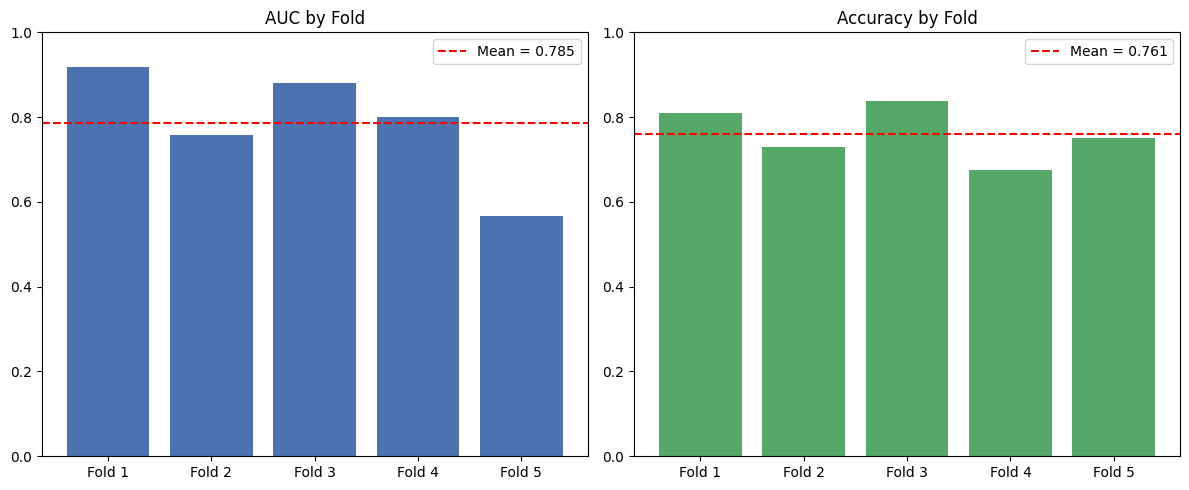

In [57]:
# NEW CELL: Per-fold AUC and Accuracy bar chart
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

folds = [f"Fold {r['fold']+1}" for r in fold_results]
aucs = [r['auc'] for r in fold_results]
accs = [r['accuracy'] for r in fold_results]

axes[0].bar(folds, aucs, color="#4C72B0")
axes[0].axhline(np.mean(aucs), color="red", linestyle="--", label=f"Mean = {np.mean(aucs):.3f}")
axes[0].set_title("AUC by Fold")
axes[0].set_ylim(0, 1)
axes[0].legend()

axes[1].bar(folds, accs, color="#55A868")
axes[1].axhline(np.mean(accs), color="red", linestyle="--", label=f"Mean = {np.mean(accs):.3f}")
axes[1].set_title("Accuracy by Fold")
axes[1].set_ylim(0, 1)
axes[1].legend()

plt.tight_layout()
plt.savefig("/content/fold_metrics_bar.png", dpi=150)
plt.show()

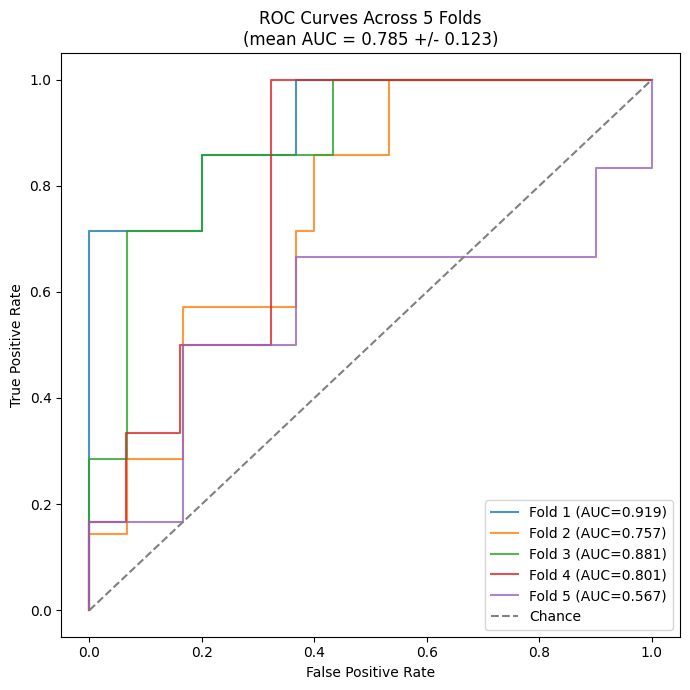

In [58]:
# NEW CELL: ROC curves overlaid across all folds
fig, ax = plt.subplots(figsize=(7, 7))
for r in fold_results:
    ax.plot(r['fpr'], r['tpr'], label=f"Fold {r['fold']+1} (AUC={r['auc']:.3f})", alpha=0.8)

ax.plot([0, 1], [0, 1], linestyle="--", color="gray", label="Chance")
ax.set_xlabel("False Positive Rate")
ax.set_ylabel("True Positive Rate")
ax.set_title(f"ROC Curves Across {N_FOLDS} Folds\n(mean AUC = {np.mean(aucs):.3f} +/- {np.std(aucs):.3f})")
ax.legend(loc="lower right")
plt.tight_layout()
plt.savefig("/content/roc_curves.png", dpi=150)
plt.show()

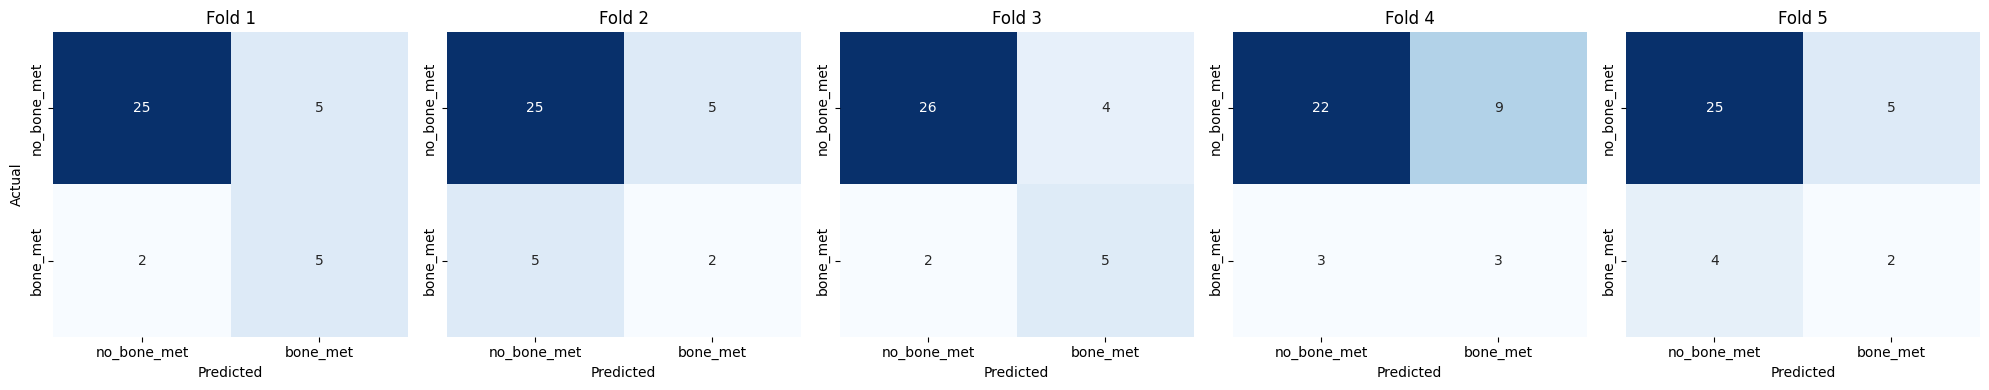

In [59]:
# NEW CELL: Confusion matrices per fold
fig, axes = plt.subplots(1, N_FOLDS, figsize=(4 * N_FOLDS, 4))
for i, r in enumerate(fold_results):
    sns.heatmap(r['confusion_matrix'], annot=True, fmt="d", cmap="Blues",
                xticklabels=["no_bone_met", "bone_met"],
                yticklabels=["no_bone_met", "bone_met"],
                ax=axes[i], cbar=False)
    axes[i].set_title(f"Fold {r['fold']+1}")
    axes[i].set_xlabel("Predicted")
    axes[i].set_ylabel("Actual" if i == 0 else "")

plt.tight_layout()
plt.savefig("/content/confusion_matrices.png", dpi=150)
plt.show()

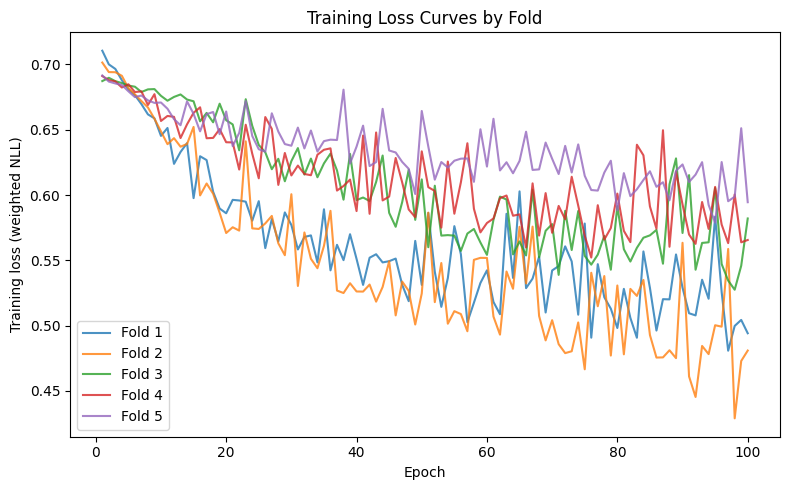

In [60]:
# NEW CELL: Training loss curves per fold
fig, ax = plt.subplots(figsize=(8, 5))
for r in fold_results:
    ax.plot(range(1, N_EPOCHS + 1), r['loss_history'], label=f"Fold {r['fold']+1}", alpha=0.8)

ax.set_xlabel("Epoch")
ax.set_ylabel("Training loss (weighted NLL)")
ax.set_title("Training Loss Curves by Fold")
ax.legend()
plt.tight_layout()
plt.savefig("/content/loss_curves.png", dpi=150)
plt.show()

Showing PPI graph from Fold 1 (best AUC = 0.9190)
53 nodes, 140 edges


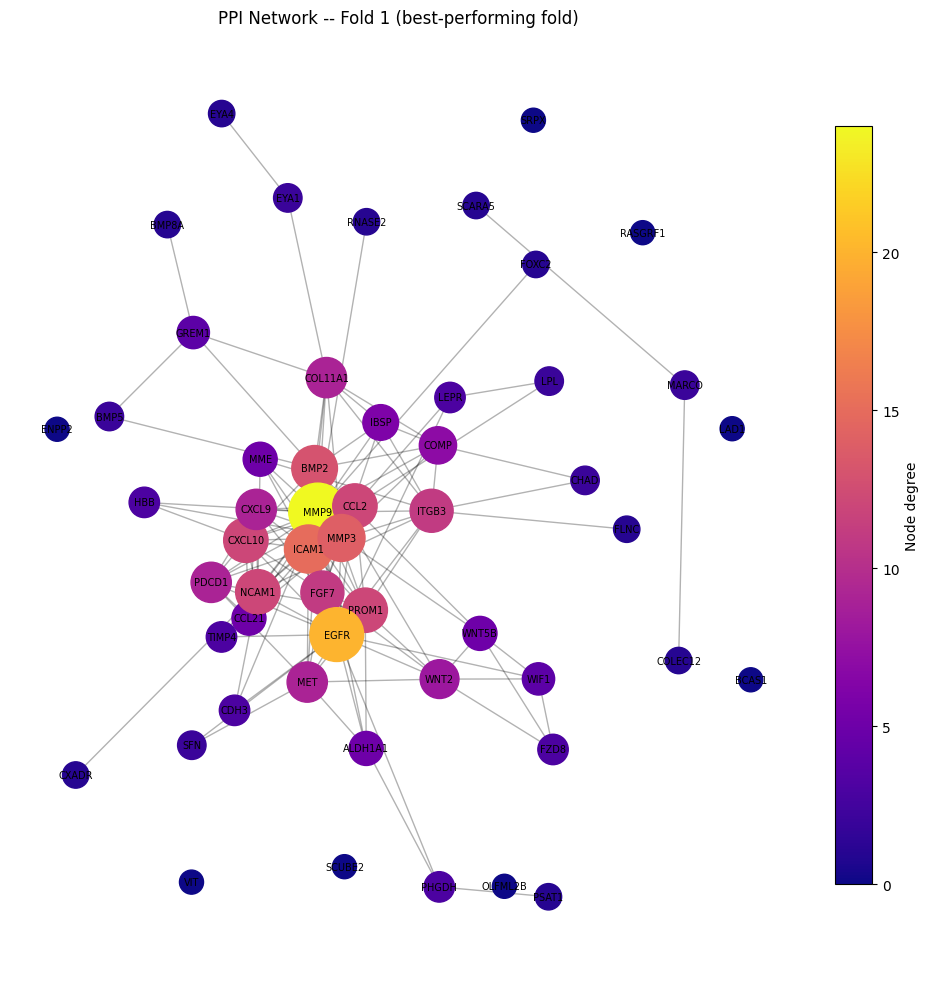

In [61]:
# NEW CELL: PPI network for the best-performing fold (highest AUC)
best_fold = max(fold_results, key=lambda r: r['auc'])
G_best = best_fold['ppi_graph']

print(f"Showing PPI graph from Fold {best_fold['fold']+1} (best AUC = {best_fold['auc']:.4f})")
print(f"{G_best.number_of_nodes()} nodes, {G_best.number_of_edges()} edges")

fig, ax = plt.subplots(figsize=(10, 10))
pos = nx.spring_layout(G_best, seed=42, k=0.5)
degrees = dict(G_best.degree())
node_sizes = [300 + 60 * degrees[n] for n in G_best.nodes()]
node_colors = [degrees[n] for n in G_best.nodes()]

nx.draw_networkx_edges(G_best, pos, alpha=0.3, ax=ax)
nodes = nx.draw_networkx_nodes(G_best, pos, node_size=node_sizes,
                                node_color=node_colors, cmap="plasma", ax=ax)
nx.draw_networkx_labels(G_best, pos, font_size=7, ax=ax)
plt.colorbar(nodes, ax=ax, label="Node degree", shrink=0.8)
ax.set_title(f"PPI Network -- Fold {best_fold['fold']+1} (best-performing fold)")
ax.axis("off")
plt.tight_layout()
plt.savefig("/content/ppi_network_best_fold.png", dpi=150)
plt.show()

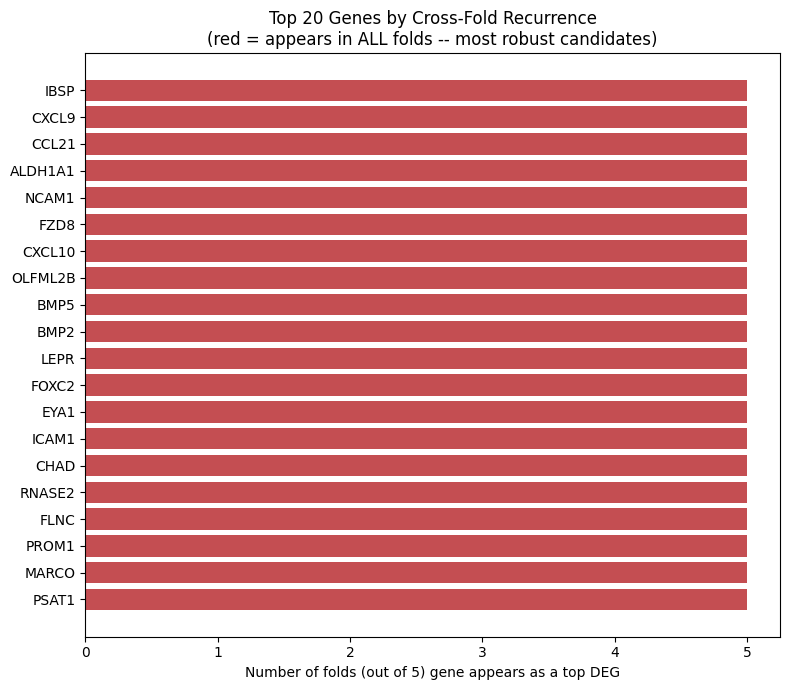


Genes appearing in ALL 5 folds: ['IBSP', 'CXCL9', 'FZD8', 'CCL21', 'ALDH1A1', 'NCAM1', 'EYA1', 'FOXC2', 'LEPR', 'BMP2', 'OLFML2B', 'BMP5', 'CXCL10', 'PROM1', 'CHAD', 'FLNC', 'RNASE2', 'ICAM1', 'ITGB3', 'MMP9', 'ENPP2', 'CDH3', 'MMP3', 'GREM1', 'VIT', 'PSAT1', 'HBB', 'WNT2', 'SFN', 'BMP8A', 'WNT5B', 'CCL2', 'EGFR', 'MARCO', 'WIF1']


In [62]:
# NEW CELL: Robust gene bar chart (genes recurring across folds)
gene_recur = pd.Series(gene_counts).sort_values(ascending=False)
top20 = gene_recur.head(20)

fig, ax = plt.subplots(figsize=(8, 7))
colors = ["#C44E52" if v == N_FOLDS else "#8172B2" for v in top20.values]
ax.barh(top20.index[::-1], top20.values[::-1], color=colors[::-1])
ax.set_xlabel(f"Number of folds (out of {N_FOLDS}) gene appears as a top DEG")
ax.set_title("Top 20 Genes by Cross-Fold Recurrence\n(red = appears in ALL folds -- most robust candidates)")
plt.tight_layout()
plt.savefig("/content/robust_genes.png", dpi=150)
plt.show()

print(f"\nGenes appearing in ALL {N_FOLDS} folds: {robust_genes}")

## Download Generated Files

Use the following cell to download all the CSV data files and generated plot images to your local machine.

In [63]:
from google.colab import files

# List of files to download
files_to_download = [
    '/content/expression_matrix.csv',
    '/content/pheno_data.csv',
    '/content/sample_labels.csv',
    '/content/expression_normalized.csv',
    '/content/class_distribution.png',
    '/content/ppi_network_preview.png',
    '/content/fold_metrics_bar.png',
    '/content/roc_curves.png',
    '/content/confusion_matrices.png',
    '/content/loss_curves.png',
    '/content/ppi_network_best_fold.png',
    '/content/robust_genes.png'
]

for file_path in files_to_download:
    try:
        files.download(file_path)
        print(f"Downloaded: {file_path}")
    except Exception as e:
        print(f"Could not download {file_path}: {e}")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Downloaded: /content/expression_matrix.csv


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

...

<IPython.core.display.Javascript object>

Downloaded: /content/ppi_network_best_fold.png


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Downloaded: /content/robust_genes.png


In [64]:
import pandas as pd

stacked_df = expr_df_full.stack().to_frame(name='Expression_Value')
stacked_df.index.names = ['Gene', 'Sample']
stacked_df.to_excel('/content/stacked_expression_data.xlsx')
print("Saved 'stacked_expression_data.xlsx' to /content/")

Saved 'stacked_expression_data.xlsx' to /content/


In [65]:
from google.colab import files

try:
    files.download('/content/stacked_expression_data.xlsx')
    print("Downloaded: /content/stacked_expression_data.xlsx")
except Exception as e:
    print(f"Could not download stacked_expression_data.xlsx: {e}")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Downloaded: /content/stacked_expression_data.xlsx
